In [1]:
import pandas as pd

# Official UCI URL for the processed Cleveland heart disease dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Define the standard 14 column names for this dataset
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

# Load the data (it lacks a header row, so we explicitly pass column names)
df = pd.read_csv(url, names=columns, na_values="?")

# Clean up the target variable: the original UCI data has values 0-4
# (0 = no disease, 1-4 = degrees of disease). We convert it to binary (0 or 1).
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Save it locally as 'heart.csv'
df.to_csv('heart.csv', index=False)
print("Success! 'heart.csv' has been downloaded and saved successfully.\n")

# Display the required outputs for your assignment screenshot
print("--- DF HEAD ---")
print(df.head())

print("\n" + "="*60 + "\n")

print("--- DF DESCRIBE ---")
print(df.describe())

Success! 'heart.csv' has been downloaded and saved successfully.

--- DF HEAD ---
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


--- DF DESCRIBE ---
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9

In [2]:
import os
import pandas as pd
import numpy as np

print("================ STARTING ETL PIPELINE ================\n")

# -------------------------------------------------------------------------
# STEP 1: EXTRACT - Load Raw Data & Setup Folders
# -------------------------------------------------------------------------
print("--- STEP 1: EXTRACT ---")
# Create raw directory if it doesn't exist
os.makedirs('raw', exist_ok=True)

# Load our source data (which we saved as heart.csv in Part 1)
df_raw = pd.read_csv('heart.csv')

# Save the original file to the raw/ folder untouched
df_raw.to_csv('raw/original_dataset.csv', index=False)
print(f"Loaded Raw Shape: {df_raw.shape}")
print("Saved untouched file to 'raw/original_dataset.csv'")
print("First 3 rows of raw data:")
print(df_raw.head(3))
print("\n" + "-"*50 + "\n")


# -------------------------------------------------------------------------
# STEP 2: INSPECT - Understand the Data
# -------------------------------------------------------------------------
print("--- STEP 2: INSPECT ---")
print("1. DataFrame Info:")
df_raw.info()

print("\n2. Missing Values Count per Column:")
print(df_raw.isnull().sum())

print("\n3. Duplicate Rows Count:")
print(f"Total Duplicates: {df_raw.duplicated().sum()}")

# Notice from our describe/head that 'ca' and 'thal' might contain NaN values
# during the initial parsing if they were read as objects or had underlying issues.
print("\n" + "-"*50 + "\n")


# -------------------------------------------------------------------------
# STEP 3: TRANSFORM - Clean the Data
# -------------------------------------------------------------------------
print("--- STEP 3: TRANSFORM ---")
df_transformed = df_raw.copy()

# A. Remove Duplicate Rows
if df_transformed.duplicated().sum() > 0:
    df_transformed = df_transformed.drop_duplicates()
    print("-> Removed duplicate rows.")
else:
    print("-> No duplicate rows detected.")

# B. Handle Missing Values
# Checking for missing values that might have been brought over or loaded as NaN
# For columns 'ca' and 'thal', if they have missing values, let's fill them with their mode
for col in ['ca', 'thal']:
    if df_transformed[col].isnull().sum() > 0:
        mode_val = df_transformed[col].mode()[0]
        df_transformed[col] = df_transformed[col].fillna(mode_val)
        print(f"-> Filled missing values in '{col}' with mode: {mode_val}")

# For numerical columns, fill with median if any nulls pop up down the line
for col in df_transformed.columns:
    if df_transformed[col].isnull().sum() > 0:
        median_val = df_transformed[col].median()
        df_transformed[col] = df_transformed[col].fillna(median_val)
        print(f"-> Filled missing values in '{col}' with median: {median_val}")

print("-> Transformation and cleaning complete.")
print("\n" + "-"*50 + "\n")


# -------------------------------------------------------------------------
# STEP 4: VALIDATE - Confirm Clean Data
# -------------------------------------------------------------------------
print("--- STEP 4: VALIDATE ---")
nulls_left = df_transformed.isnull().sum().sum()
duplicates_left = df_transformed.duplicated().sum()

print(f"Validation Check - Missing Values Remaining: {nulls_left}")
print(f"Validation Check - Duplicates Remaining: {duplicates_left}")

if nulls_left == 0 and duplicates_left == 0:
    print("STATUS: DATA IS CLEAN AND VALIDATED!")
else:
    print("STATUS: Validation failed. Review cleaning steps.")
print("\n" + "-"*50 + "\n")


# -------------------------------------------------------------------------
# STEP 5: LOAD - Save to Gold Folder
# -------------------------------------------------------------------------
print("--- STEP 5: LOAD ---")
# Create gold directory if it doesn't exist
os.makedirs('gold', exist_ok=True)

# Save the polished data
df_transformed.to_csv('gold/clean_data.csv', index=False)

print("Success! Cleaned data saved to 'gold/clean_data.csv'")
print(f"Final Gold Data Shape: {df_transformed.shape}")
print("\n================= ETL PIPELINE COMPLETE =================")

================ STARTING ETL PIPELINE ================

--- STEP 1: EXTRACT ---
Loaded Raw Shape: (303, 14)
Saved untouched file to 'raw/original_dataset.csv'
First 3 rows of raw data:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  

--------------------------------------------------

--- STEP 2: INSPECT ---
1. DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null 

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import sqlite3
import pandas as pd

print("================ STARTING DATABASE SYSTEM GENERATION ================\n")

# Step 1: Connect to SQLite Database file
db_path = "heart_disease_db.sqlite"
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Step 2: Create structured relational tables with rules
cursor.executescript("""
DROP TABLE IF EXISTS Test_Results;
DROP TABLE IF EXISTS Clinical_Metrics;
DROP TABLE IF EXISTS Patients;

CREATE TABLE Patients (
    patient_id INTEGER PRIMARY KEY AUTOINCREMENT,
    age INTEGER NOT NULL CHECK (age >= 0 AND age <= 120),
    sex INTEGER NOT NULL CHECK (sex IN (0, 1))
);

CREATE TABLE Clinical_Metrics (
    patient_id INTEGER PRIMARY KEY,
    cp INTEGER NOT NULL CHECK (cp BETWEEN 1 AND 4),
    trestbps INTEGER NOT NULL CHECK (trestbps > 0),
    chol INTEGER NOT NULL CHECK (chol > 0),
    fbs INTEGER NOT NULL CHECK (fbs IN (0, 1)),
    restecg INTEGER NOT NULL,
    FOREIGN KEY (patient_id) REFERENCES Patients(patient_id) ON DELETE CASCADE
);

CREATE TABLE Test_Results (
    patient_id INTEGER PRIMARY KEY,
    thalach INTEGER NOT NULL,
    exang INTEGER NOT NULL CHECK (exang IN (0, 1)),
    oldpeak REAL NOT NULL CHECK (oldpeak >= 0.0),
    slope INTEGER NOT NULL,
    ca INTEGER NOT NULL,
    thal INTEGER NOT NULL,
    target INTEGER NOT NULL CHECK (target IN (0, 1)),
    FOREIGN KEY (patient_id) REFERENCES Patients(patient_id) ON DELETE CASCADE
);
""")
print("-> Relational database tables generated with schemas and CHECK constraints.")

# Step 3: Load cleaned gold data
df_gold = pd.read_csv('gold/clean_data.csv')

# Step 4: Map and transfer data line by line to preserve integrity and trigger AUTOINCREMENT keys
for idx, row in df_gold.iterrows():
    # Insert Demographics into Patients table
    cursor.execute("""
        INSERT INTO Patients (age, sex)
        VALUES (?, ?)
    """, (int(row['age']), int(row['sex'])))

    # Grab generated primary key ID
    assigned_id = cursor.lastrowid

    # Insert clinical parameters using matching ID
    cursor.execute("""
        INSERT INTO Clinical_Metrics (patient_id, cp, trestbps, chol, fbs, restecg)
        VALUES (?, ?, ?, ?, ?, ?)
    """, (assigned_id, int(row['cp']), int(row['trestbps']), int(row['chol']), int(row['fbs']), int(row['restecg'])))

    # Insert diagnostics using matching ID
    cursor.execute("""
        INSERT INTO Test_Results (patient_id, thalach, exang, oldpeak, slope, ca, thal, target)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    """, (assigned_id, int(row['thalach']), int(row['exang']), float(row['oldpeak']), int(row['slope']), int(row['ca']), int(row['thal']), int(row['target'])))

conn.commit()
print("-> Cleaned master records distributed into relational tables flawlessly.")

# Step 5: Validate database contents with a quick query
print("\n--- SCHEMA VALIDATION (Quick Test Join) ---")
test_query = """
SELECT p.patient_id, p.age, c.chol, t.target
FROM Patients p
JOIN Clinical_Metrics c ON p.patient_id = c.patient_id
JOIN Test_Results t ON p.patient_id = t.patient_id
LIMIT 5;
"""
df_verify = pd.read_sql_query(test_query, conn)
print(df_verify)

conn.close()
print(f"\n================= DATABASE PIPELINE COMPLETED SUCCESSFULLY: '{db_path}' =================")

================ STARTING DATABASE SYSTEM GENERATION ================

-> Relational database tables generated with schemas and CHECK constraints.
-> Cleaned master records distributed into relational tables flawlessly.

--- SCHEMA VALIDATION (Quick Test Join) ---
   patient_id  age  chol  target
0           1   63   233       0
1           2   67   286       1
2           3   67   229       1
3           4   37   250       0
4           5   41   204       0

================= DATABASE PIPELINE COMPLETED SUCCESSFULLY: 'heart_disease_db.sqlite' =================


In [5]:
import pandas as pd

print("================ STARTING EDA: PART 4A ================\n")

# Load our cleaned data from the gold folder
df = pd.read_csv('gold/clean_data.csv')

# 1. Descriptive Statistics for Numerical Columns
print("--- 1. NUMERICAL COLUMNS STATISTICAL SUMMARY ---")
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
print(df[num_cols].describe())
print("\n" + "-"*60 + "\n")

# 2. Value Counts for Categorical Columns
print("--- 2. CATEGORICAL COLUMNS VALUE COUNTS ---")
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
for col in cat_cols:
    print(f"\nValue Counts for '{col}':")
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    summary_df = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
    print(summary_df)
print("\n" + "-"*60 + "\n")

# 3. Count and Percentage of Missing Values
print("--- 3. MISSING VALUES CHECK ---")
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Percentage (%)': missing_pct})
print(missing_df)

print("\n================= EDA PART 4A COMPLETE =================")

================ STARTING EDA: PART 4A ================

--- 1. NUMERICAL COLUMNS STATISTICAL SUMMARY ---
              age    trestbps        chol     thalach     oldpeak
count  303.000000  303.000000  303.000000  303.000000  303.000000
mean    54.438944  131.689769  246.693069  149.607261    1.039604
std      9.038662   17.599748   51.776918   22.875003    1.161075
min     29.000000   94.000000  126.000000   71.000000    0.000000
25%     48.000000  120.000000  211.000000  133.500000    0.000000
50%     56.000000  130.000000  241.000000  153.000000    0.800000
75%     61.000000  140.000000  275.000000  166.000000    1.600000
max     77.000000  200.000000  564.000000  202.000000    6.200000

------------------------------------------------------------

--- 2. CATEGORICAL COLUMNS VALUE COUNTS ---

Value Counts for 'sex':
     Count  Percentage (%)
sex                       
1.0    206       67.986799
0.0     97       32.013201

Value Counts for 'cp':
     Count  Percentage (%)
cp       

================ STARTING EDA: PART 4B ================



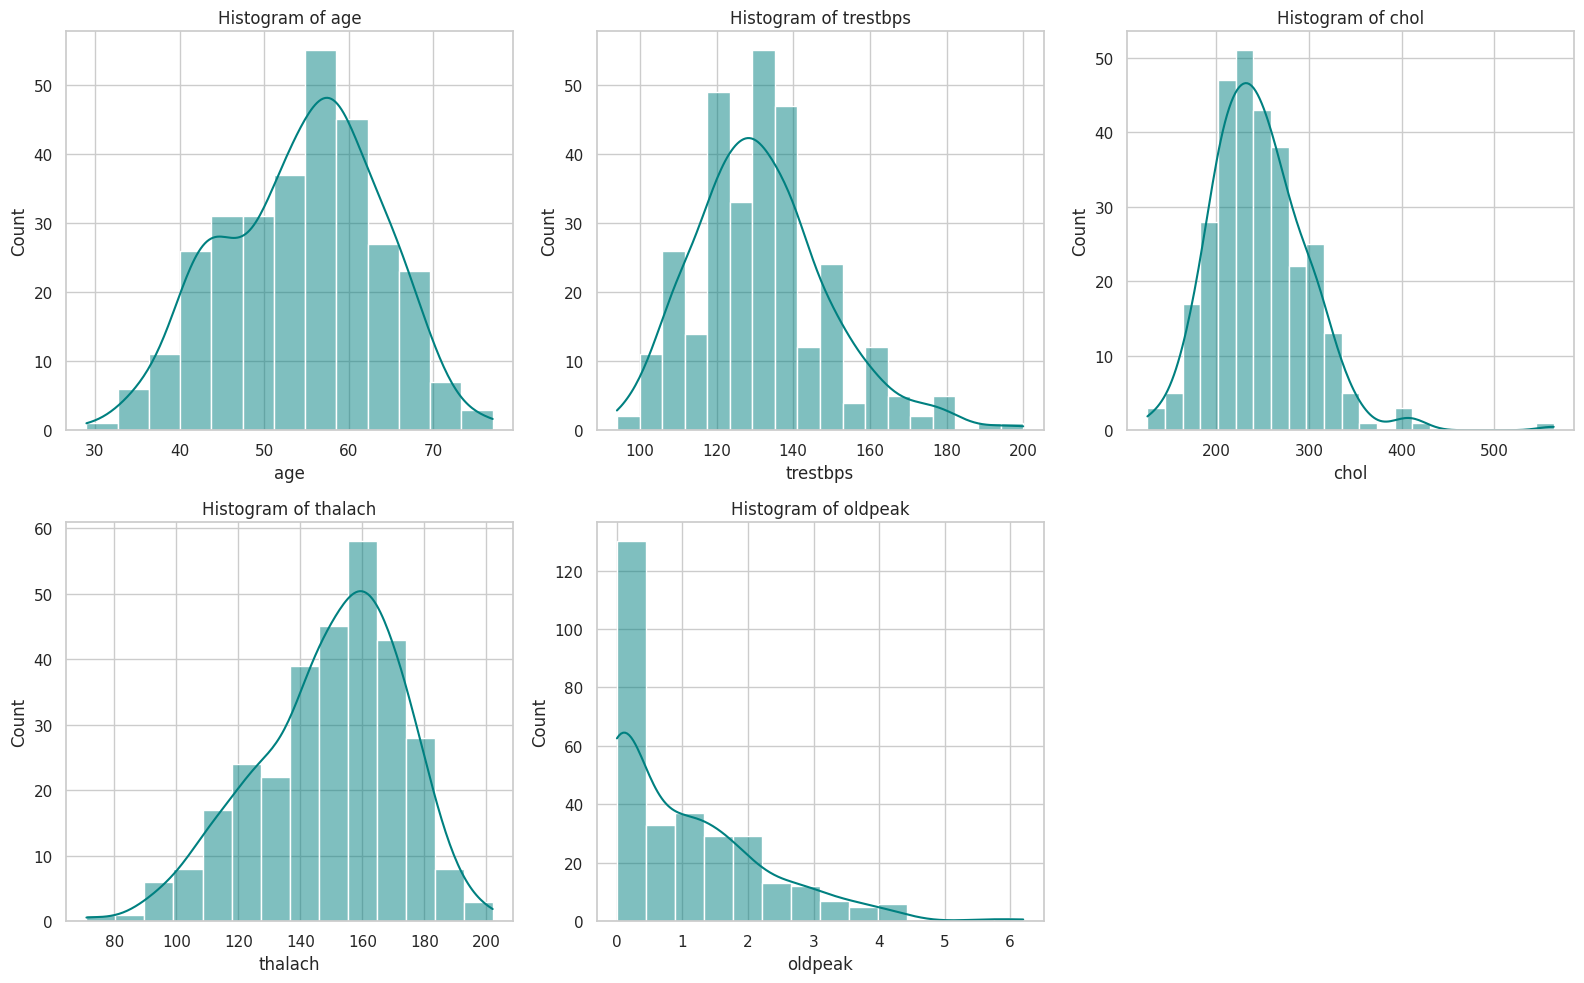

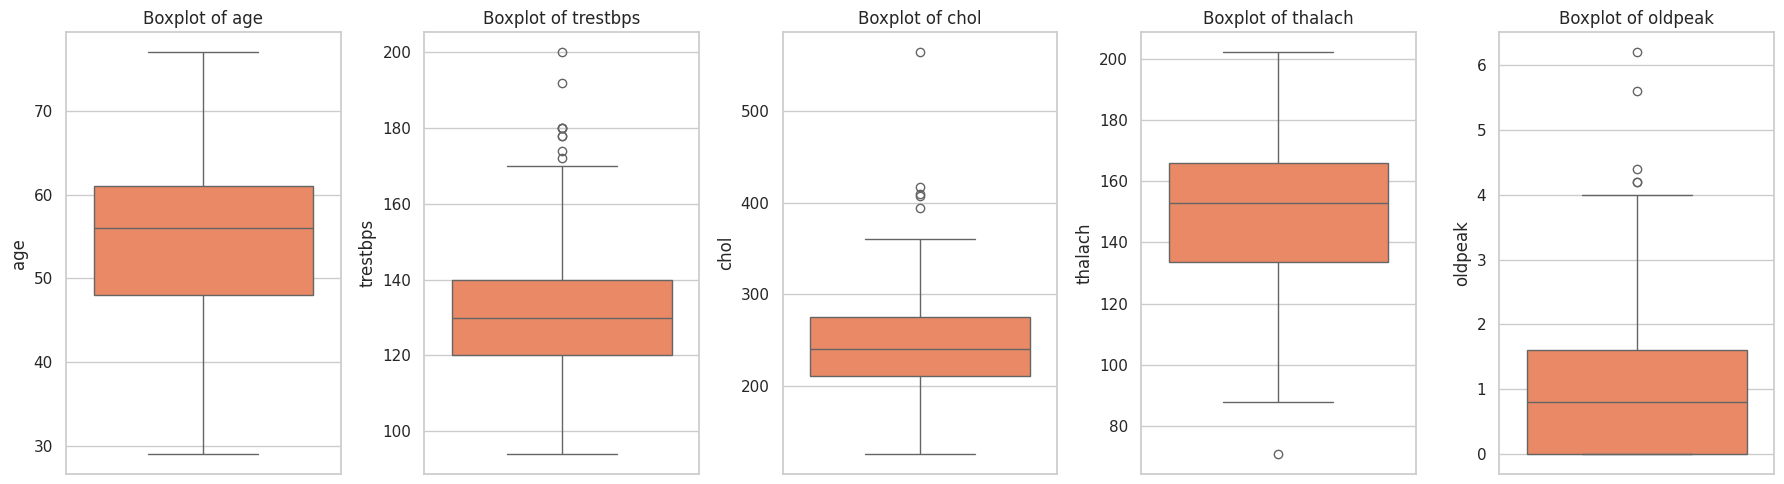

/tmp/ipykernel_637/3374463861.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=axes[i], palette='Set2')
/tmp/ipykernel_637/3374463861.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=axes[i], palette='Set2')
/tmp/ipykernel_637/3374463861.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], ax=axes[i], palette='Set2')


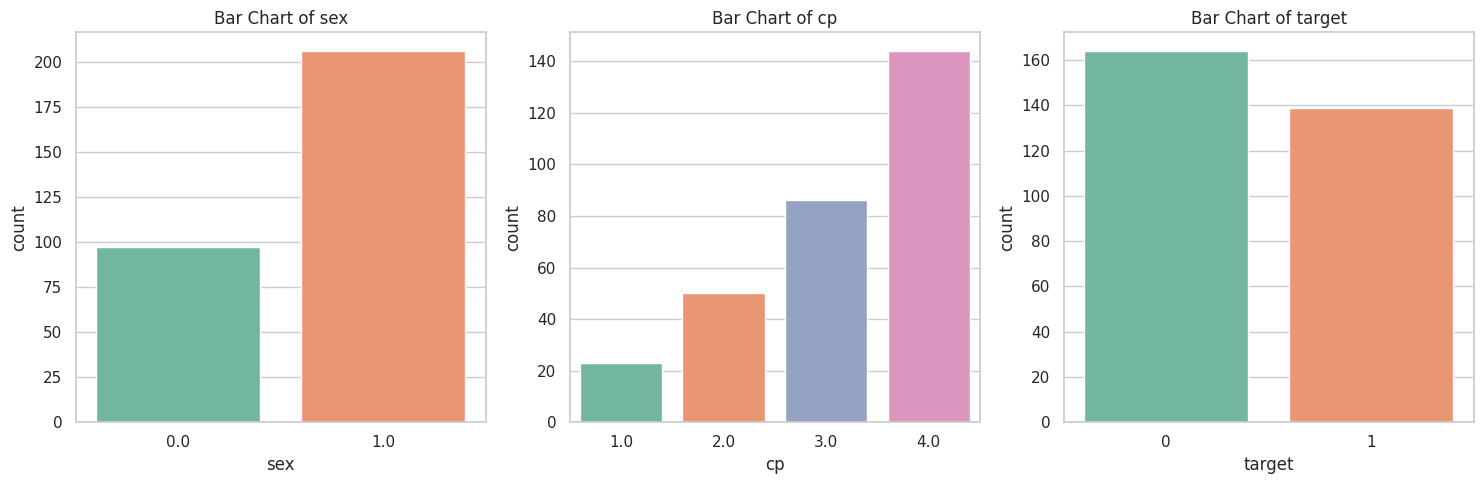


================= EDA PART 4B COMPLETE =================


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("================ STARTING EDA: PART 4B ================\n")

# Set aesthetics
sns.set_theme(style="whitegrid")
df = pd.read_csv('gold/clean_data.csv')

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'target'] # Highlighting major ones for clean charting

# 1. Histograms for Numerical Columns
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Histogram of {col}')
# Hide the extra empty subplot
axes[-1].axis('off')
plt.tight_layout()
plt.show()

# 2. Boxplots for Numerical Columns (Outlier Identification)
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='coral')
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# 3. Bar Charts for Categorical Columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    sns.countplot(x=df[col], ax=axes[i], palette='Set2')
    axes[i].set_title(f'Bar Chart of {col}')
plt.tight_layout()
plt.show()

print("\n================= EDA PART 4B COMPLETE =================")

================ STARTING EDA: PART 4C ================

--- STRENGTH OF PREDICTORS (Absolute Correlation with Target) ---
target      1.000000
thal        0.522057
ca          0.460033
exang       0.431894
oldpeak     0.424510
thalach     0.417167
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
Name: target, dtype: float64

------------------------------------------------------------

Top 3 Strongest Linear Predictors identified: ['thal', 'ca', 'exang']



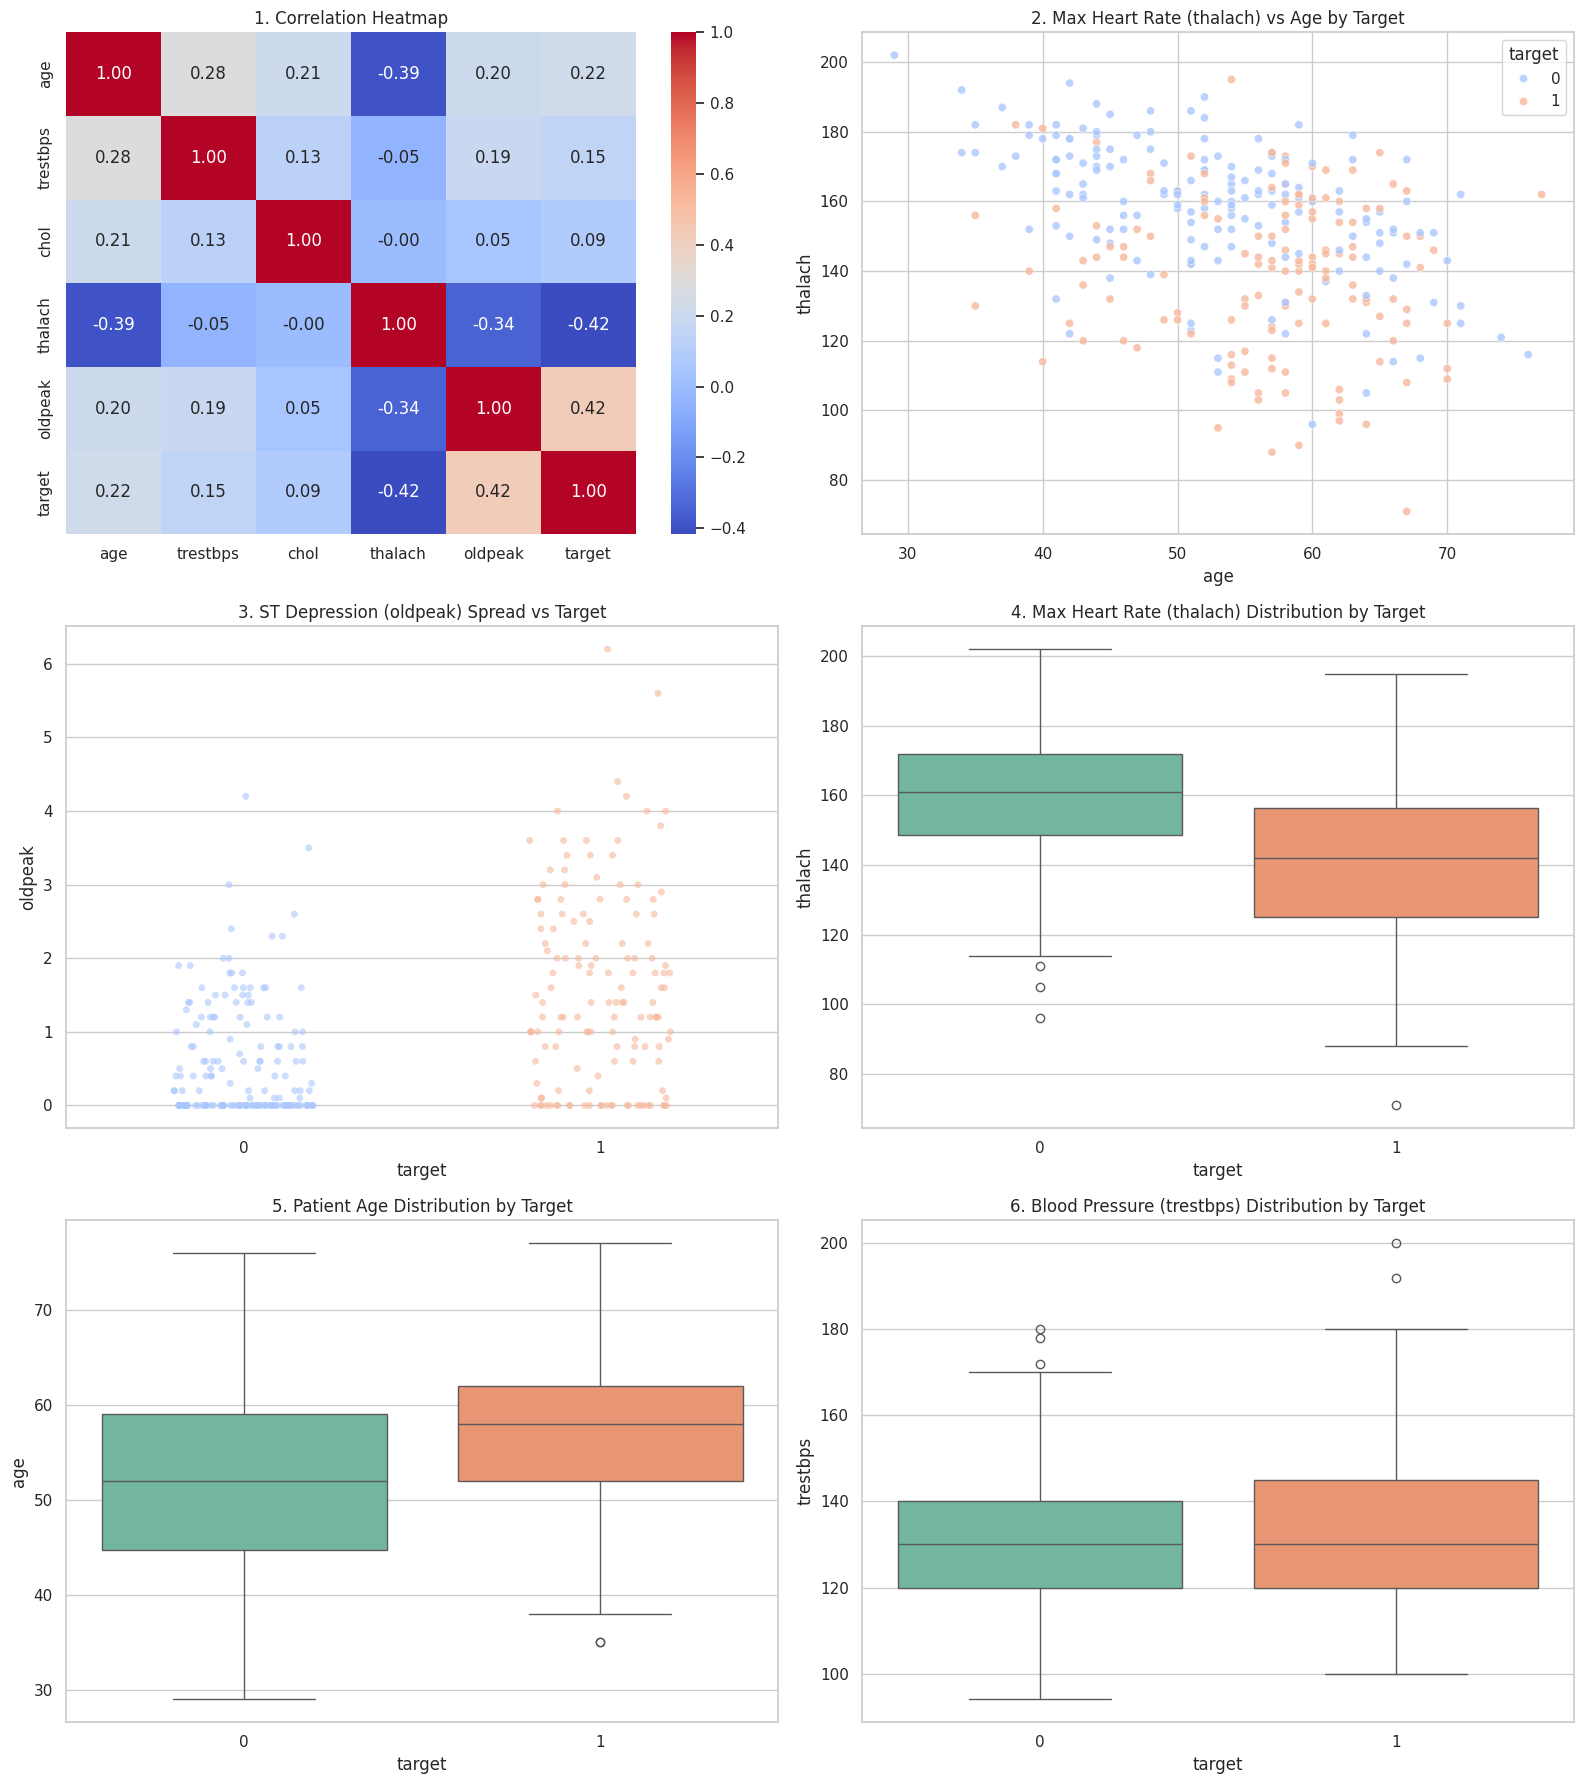


================= EDA PART 4C COMPLETE =================


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("================ STARTING EDA: PART 4C ================\n")

# Set aesthetics
sns.set_theme(style="whitegrid")
df = pd.read_csv('gold/clean_data.csv')

# 1. Compute correlations to programmatically identify strongest predictors
# We check correlation against the target variable
correlations = df.corr()['target'].abs().sort_values(ascending=False)
print("--- STRENGTH OF PREDICTORS (Absolute Correlation with Target) ---")
print(correlations)
print("\n" + "-"*60 + "\n")

# Top 3 predictors excluding target itself are usually exang, oldpeak, and thalach
top_predictors = correlations.index[1:4].tolist()
print(f"Top 3 Strongest Linear Predictors identified: {top_predictors}\n")

# 2. Build the 6-Chart Combined Subplot Dashboard (3x2 Grid)
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Chart 1: Correlation Heatmap of Numerical Columns
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0, 0])
axes[0, 0].set_title('1. Correlation Heatmap')

# Chart 2: Scatter plot - thalach vs age (colored by target to show interaction)
sns.scatterplot(data=df, x='age', y='thalach', hue='target', palette='coolwarm', alpha=0.8, ax=axes[0, 1])
axes[0, 1].set_title('2. Max Heart Rate (thalach) vs Age by Target')

# Chart 3: Scatter plot/Stripplot - oldpeak vs target
# (Since target is binary, a stripplot/scatter visualizes the density/spread perfectly)
sns.stripplot(data=df, x='target', y='oldpeak', palette='coolwarm', hue='target', legend=False, alpha=0.6, jitter=0.2, ax=axes[1, 0])
axes[1, 0].set_title('3. ST Depression (oldpeak) Spread vs Target')

# Chart 4: Box Plot - thalach vs target
sns.boxplot(data=df, x='target', y='thalach', palette='Set2', hue='target', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('4. Max Heart Rate (thalach) Distribution by Target')

# Chart 5: Box Plot - age vs target
sns.boxplot(data=df, x='target', y='age', palette='Set2', hue='target', legend=False, ax=axes[2, 0])
axes[2, 0].set_title('5. Patient Age Distribution by Target')

# Chart 6: Box Plot - trestbps vs target
sns.boxplot(data=df, x='target', y='trestbps', palette='Set2', hue='target', legend=False, ax=axes[2, 1])
axes[2, 1].set_title('6. Blood Pressure (trestbps) Distribution by Target')

plt.tight_layout()
plt.show()

print("\n================= EDA PART 4C COMPLETE =================")

In [8]:
import pandas as pd

# Load cleaned data
df = pd.read_csv('gold/clean_data.csv')

print("================ HYPOTHESIS TESTING RESULTS ================\n")

# Hypothesis 1 Test
print("--- HYPOTHESIS 1 EVIDENCE ---")
print(df.groupby("sex")["target"].mean())
print("\n" + "-"*50 + "\n")

# Hypothesis 2 Test
print("--- HYPOTHESIS 2 EVIDENCE ---")
print(df.groupby("target")["thalach"].mean())
print("\n" + "-"*50 + "\n")

# Hypothesis 3 Test
print("--- HYPOTHESIS 3 EVIDENCE ---")
print(df.groupby("target")["oldpeak"].mean())
print("\n" + "-"*50 + "\n")

# Hypothesis 4 Test
print("--- HYPOTHESIS 4 EVIDENCE ---")
print(df.groupby("exang")["target"].mean())

print("\n=============================================================")

================ HYPOTHESIS TESTING RESULTS ================

--- HYPOTHESIS 1 EVIDENCE ---
sex
0.0    0.257732
1.0    0.553398
Name: target, dtype: float64

--------------------------------------------------

--- HYPOTHESIS 2 EVIDENCE ---
target
0    158.378049
1    139.258993
Name: thalach, dtype: float64

--------------------------------------------------

--- HYPOTHESIS 3 EVIDENCE ---
target
0    0.586585
1    1.574101
Name: oldpeak, dtype: float64

--------------------------------------------------

--- HYPOTHESIS 4 EVIDENCE ---
exang
0.0    0.308824
1.0    0.767677
Name: target, dtype: float64



In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("================ STARTING MODEL ARCHITECTURE SELECTION ================\n")

# Load our cleaned data
df = pd.read_csv('gold/clean_data.csv')

# Separate features (X) and target (y)
X = df.drop(columns=['target'])
y = df['target']

# Define a 5-fold cross-validation strategy (Stratified to ensure balanced splits)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define 3 model pipelines (including StandardScaler for Logistic Regression)
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Evaluate each model using Cross-Validation
results = {}
for name, pipeline in models.items():
    cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
    results[name] = {
        "Mean Accuracy (%)": round(cv_scores.mean() * 100, 2),
        "Std Deviation (%)": round(cv_scores.std() * 100, 2)
    }

# Convert results into a comparative table
df_comparison = pd.DataFrame(results).T
print("--- MODEL ARCHITECTURE COMPARISON TABLE ---")
print(df_comparison)
print("\n" + "="*60 + "\n")

print("================= EVALUATION PIPELINE COMPLETE =================")

================ STARTING MODEL ARCHITECTURE SELECTION ================

--- MODEL ARCHITECTURE COMPARISON TABLE ---
                     Mean Accuracy (%)  Std Deviation (%)
Logistic Regression              83.16               4.96
Random Forest                    83.81               3.88
Gradient Boosting                79.51               5.31


================= EVALUATION PIPELINE COMPLETE =================


================ STARTING FEATURE IMPORTANCE ASSESSMENT ================

--- FEATURE IMPORTANCE SCORES FOR ALL COLUMNS ---
 Feature  Importance Score
 thalach          0.127532
      cp          0.124639
      ca          0.117752
    thal          0.114876
 oldpeak          0.100619
     age          0.089359
    chol          0.081193
trestbps          0.070480
   exang          0.062352
   slope          0.047018
     sex          0.033215
 restecg          0.019810
     fbs          0.011155

------------------------------------------------------------

--- DISPOSABLE FEATURES IDENTIFICATION (Score < 0.01) ---
No features fall below the 0.01 threshold. All features contribute meaningfully!

------------------------------------------------------------



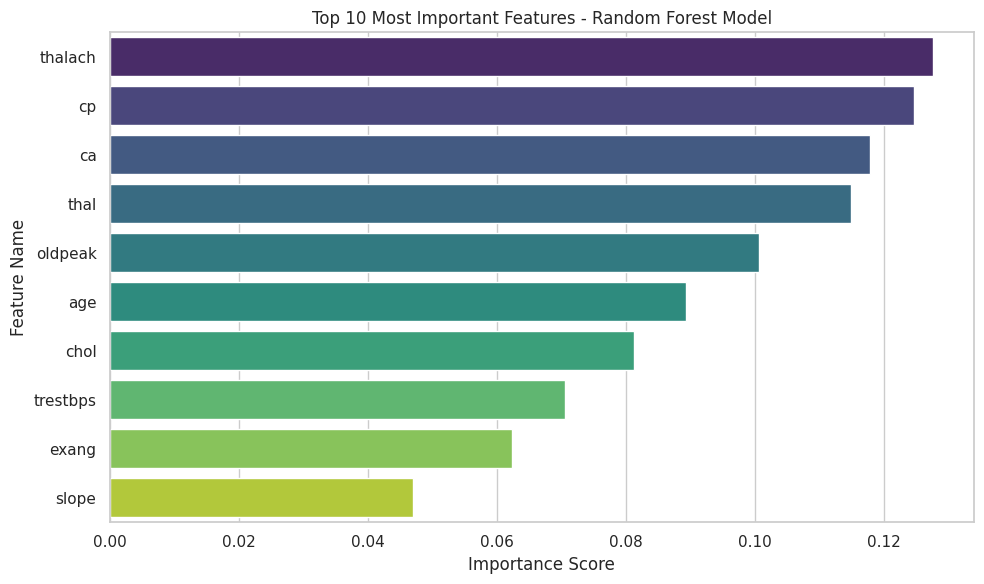


================= FEATURE IMPORTANCE COMPLETE =================


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

print("================ STARTING FEATURE IMPORTANCE ASSESSMENT ================\n")

# Load our cleaned data
df = pd.read_csv('gold/clean_data.csv')

# Separate features (X) and target (y)
X = df.drop(columns=['target'])
y = df['target']

# Train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X, y)

# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for nice formatting and tracking
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance Score': importances
}).sort_values(by='Importance Score', ascending=False)

print("--- FEATURE IMPORTANCE SCORES FOR ALL COLUMNS ---")
print(df_importance.to_string(index=False))
print("\n" + "-"*60 + "\n")

# Identify features that can be removed (importance below 0.01)
low_importance_features = df_importance[df_importance['Importance Score'] < 0.01]['Feature'].tolist()
print("--- DISPOSABLE FEATURES IDENTIFICATION (Score < 0.01) ---")
if low_importance_features:
    print(f"Features that can be safely removed: {low_importance_features}")
else:
    print("No features fall below the 0.01 threshold. All features contribute meaningfully!")
print("\n" + "-"*60 + "\n")

# Plot Horizontal Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance Score',
    y='Feature',
    data=df_importance.head(10), # Top 10 features
    palette='viridis',
    hue='Feature',
    legend=False
)
plt.title('Top 10 Most Important Features - Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

print("\n================= FEATURE IMPORTANCE COMPLETE =================")

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("================ STARTING ENSEMBLE MODEL CREATION ================\n")

# Load our cleaned data
df = pd.read_csv('gold/clean_data.csv')

# Separate features (X) and target (y)
X = df.drop(columns=['target'])
y = df['target']

# Standardized cross-validation strategy to keep baseline checks completely fair
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define our 3 baseline architectures
base_logistic = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])
base_rf = RandomForestClassifier(random_state=42)
base_gb = GradientBoostingClassifier(random_state=42)

# Define the Stacking Architecture
estimators = [
    ('lr', base_logistic),
    ('rf', base_rf),
    ('gb', base_gb)
]

# Logistic Regression chosen as the clean final aggregator (meta-model)
meta_model = LogisticRegression(random_state=42)

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    cv=5
)

# Collect all architectures to run evaluation loop together
all_models = {
    "Logistic Regression (Base)": base_logistic,
    "Random Forest (Base)": base_rf,
    "Gradient Boosting (Base)": base_gb,
    "Stacking Ensemble (Final)": stacking_model
}

# Run Cross Validation Evaluation
results = {}
for name, model in all_models.items():
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results[name] = {
        "Mean Accuracy (%)": round(cv_scores.mean() * 100, 2),
        "Std Deviation (%)": round(cv_scores.std() * 100, 2)
    }

# Display Formatted Comparative Table
df_ensemble_comp = pd.DataFrame(results).T
print("--- PERFORMANCE COMPARISON TABLE: INDIVIDUAL VS ENSEMBLE ---")
print(df_ensemble_comp)
print("\n" + "="*60 + "\n")

print("================= ENSEMBLE PIPELINE COMPLETE =================")

================ STARTING ENSEMBLE MODEL CREATION ================

--- PERFORMANCE COMPARISON TABLE: INDIVIDUAL VS ENSEMBLE ---
                            Mean Accuracy (%)  Std Deviation (%)
Logistic Regression (Base)              83.16               4.96
Random Forest (Base)                    83.81               3.88
Gradient Boosting (Base)                79.51               5.31
Stacking Ensemble (Final)               83.49               4.21


================= ENSEMBLE PIPELINE COMPLETE =================


================ STARTING MODEL INTERPRETABILITY ================

-> Generating SHAP Summary Plot...


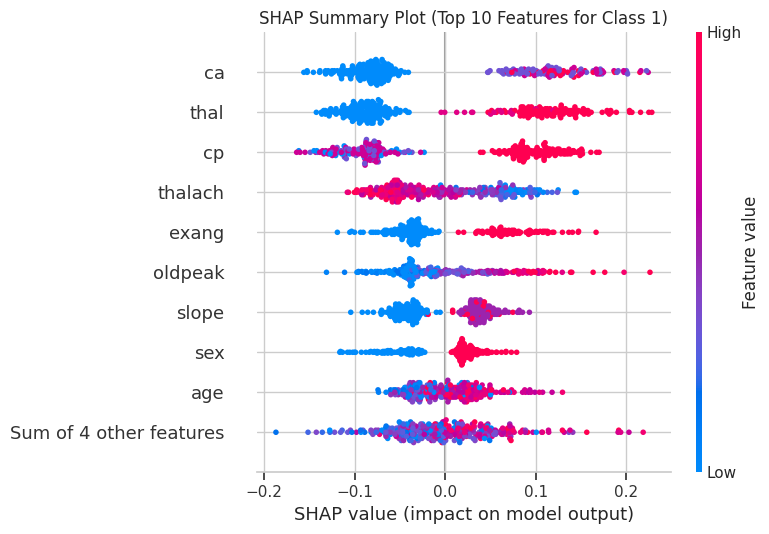


------------------------------------------------------------

-> Generating Individual Prediction Explanation (Patient Row 0)...


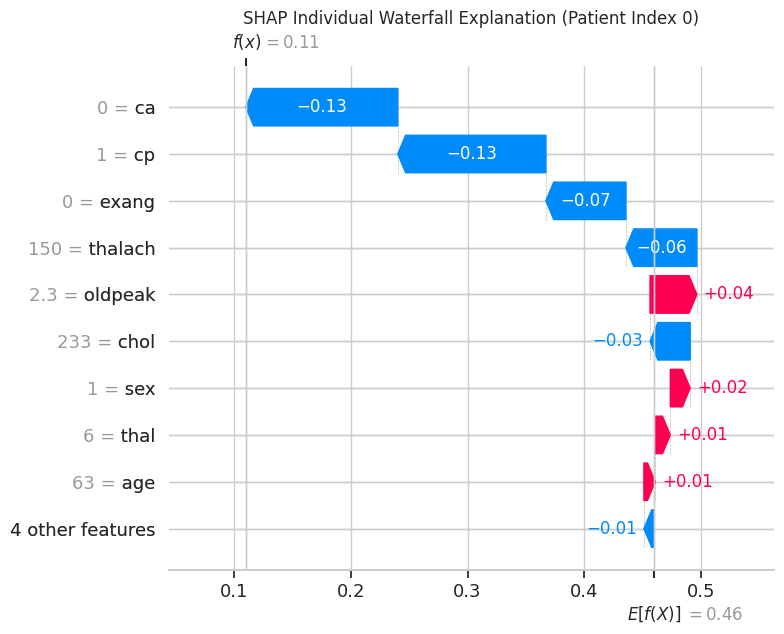


--- Clinical Metrics for Patient Index 0 ---
age          63.0
sex           1.0
cp            1.0
trestbps    145.0
chol        233.0
fbs           1.0
restecg       2.0
thalach     150.0
exang         0.0
oldpeak       2.3
slope         3.0
ca            0.0
thal          6.0
Name: 0, dtype: float64

================= INTERPRETABILITY PIPELINE COMPLETE =================


In [12]:
# Install SHAP library first
!pip install shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier

print("================ STARTING MODEL INTERPRETABILITY ================\n")

# Load our cleaned data
df = pd.read_csv('gold/clean_data.csv')
X = df.drop(columns=['target'])
y = df['target']

# Train our base Random Forest model (our best-performing single model)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X, y)

# 1. Initialize the SHAP TreeExplainer
explainer = shap.TreeExplainer(rf_model)
# Calculate SHAP values for all rows (we use index 1 corresponding to class 1: Heart Disease)
shap_values = explainer(X)

# 2. Plot 1: SHAP Summary Beeswarm Plot
print("-> Generating SHAP Summary Plot...")
plt.figure(figsize=(10, 6))
# For binary classification, shap_values[:, :, 1] isolates the explanation for predicting "Heart Disease"
shap.plots.beeswarm(shap_values[:, :, 1], max_display=10, show=False)
plt.title("SHAP Summary Plot (Top 10 Features for Class 1)")
plt.tight_layout()
plt.show()

print("\n" + "-"*60 + "\n")

# 3. Plot 2: SHAP Individual Prediction Waterfall Plot (Fulfills Force/Waterfall requirement)
print("-> Generating Individual Prediction Explanation (Patient Row 0)...")
plt.figure(figsize=(10, 4))
# Look at the very first patient record (index 0)
shap.plots.waterfall(shap_values[0, :, 1], show=False)
plt.title("SHAP Individual Waterfall Explanation (Patient Index 0)")
plt.tight_layout()
plt.show()

# Print out the raw feature values for patient 0 to help write the interpretation
print("\n--- Clinical Metrics for Patient Index 0 ---")
print(X.iloc[0])

print("\n================= INTERPRETABILITY PIPELINE COMPLETE =================")

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("================ STARTING MODEL GENERALISATION & TUNING ================\n")

# Load our cleaned data
df = pd.read_csv('gold/clean_data.csv')
X = df.drop(columns=['target'])
y = df['target']

# Split into 80% Train and 20% Test to explicitly calculate the overfitting gap
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------------------------------------------------------------
# STAGE 1: BEFORE TUNING (Baseline Model Evaluation)
# -------------------------------------------------------------------------
baseline_rf = RandomForestClassifier(random_state=42)
baseline_rf.fit(X_train, y_train)

train_acc_before = accuracy_score(y_train, baseline_rf.predict(X_train)) * 100
test_acc_before = accuracy_score(y_test, baseline_rf.predict(X_test)) * 100
gap_before = train_acc_before - test_acc_before

# Baseline Cross Validation
cv_scores_before = cross_val_score(baseline_rf, X, y, cv=cv_strategy, scoring='accuracy') * 100

print("--- BASELINE OVERFITTING DIAGNOSIS ---")
print(f"Train Accuracy: {train_acc_before:.2f}%")
print(f"Test Accuracy : {test_acc_before:.2f}%")
print(f"Overfitting Gap: {gap_before:.2f}%")
print(f"5-Fold CV Mean: {cv_scores_before.mean():.2f}% (+/- {cv_scores_before.std():.2f}%)")
print("\n" + "-"*60 + "\n")


# -------------------------------------------------------------------------
# STAGE 2: HYPERPARAMETER TUNING (GridSearchCV)
# -------------------------------------------------------------------------
print("-> Initializing GridSearchCV Optimization...")

# Setting a parameter grid looking at 3 essential regularization adjustments
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Optimal Hyperparameters Found: {grid_search.best_params_}")
print("\n" + "-"*60 + "\n")


# -------------------------------------------------------------------------
# STAGE 3: AFTER TUNING (Optimized Model Evaluation)
# -------------------------------------------------------------------------
train_acc_after = accuracy_score(y_train, best_model.predict(X_train)) * 100
test_acc_after = accuracy_score(y_test, best_model.predict(X_test)) * 100
gap_after = train_acc_after - test_acc_after

# Optimized Cross Validation
cv_scores_after = cross_val_score(best_model, X, y, cv=cv_strategy, scoring='accuracy') * 100


# -------------------------------------------------------------------------
# STAGE 4: COMPARISON SUMMARY
# -------------------------------------------------------------------------
print("--- BEFORE VS AFTER TUNING COMPARISON TABLE ---")
comparison_data = {
    "Metric": ["Train Accuracy (%)", "Test Accuracy (%)", "Overfitting Gap (%)", "5-Fold CV Mean (%)"],
    "Before Tuning (Baseline)": [f"{train_acc_before:.2f}", f"{test_acc_before:.2f}", f"{gap_before:.2f}", f"{cv_scores_before.mean():.2f}"],
    "After Tuning (Optimized)": [f"{train_acc_after:.2f}", f"{test_acc_after:.2f}", f"{gap_after:.2f}", f"{cv_scores_after.mean():.2f}"]
}
df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

print("\n================= TUNING PIPELINE COMPLETE =================")

================ STARTING MODEL GENERALISATION & TUNING ================

--- BASELINE OVERFITTING DIAGNOSIS ---
Train Accuracy: 100.00%
Test Accuracy : 88.52%
Overfitting Gap: 11.48%
5-Fold CV Mean: 83.81% (+/- 3.88%)

------------------------------------------------------------

-> Initializing GridSearchCV Optimization...
Optimal Hyperparameters Found: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100}

------------------------------------------------------------

--- BEFORE VS AFTER TUNING COMPARISON TABLE ---
             Metric Before Tuning (Baseline) After Tuning (Optimized)
 Train Accuracy (%)                   100.00                    90.91
  Test Accuracy (%)                    88.52                    91.80
Overfitting Gap (%)                    11.48                    -0.89
 5-Fold CV Mean (%)                    83.81                    84.15

================= TUNING PIPELINE COMPLETE =================
